# Client B: DEAD (Drinking Excess Alcohol is Dangerous) — Zip-Month Purchase Drivers

**Client:** DEAD, an Iowa nonprofit working on safer alcohol culture. **Their question:**
what factors drive higher or lower alcohol purchases, by area and by month.

**Target: liters per capita**, from zip population pulled via the Census API in section 5
-- not raw liters (confounded by zip size) and not dollars (confounded by price).

**Read section 1b first: this data is almost certainly spirits only.** Iowa's Alcoholic
Beverages Division has held exclusive wholesale control of *spirits* since 1934, but gave
up control of wine in 1985 and never controlled beer -- both are distributed privately and
don't appear to be reflected in `category_name` here. If that holds, **none of this
notebook says anything about beer or wine purchases**, which matters a lot for a client
concerned with alcohol broadly, not spirits specifically. Section 1b checks this against
the actual category list rather than asserting it.

**Two views, not one:** section 11 gives statewide "when" drivers; section 12 gives a
"where" companion for Iowa City / Ames specifically, since a pooled statewide model
structurally cannot see effects that are large in two college towns and near-zero
everywhere else (the Hawkeyes/Cyclones/Iowa State Fair coefficients in section 11 are a
symptom of this, not evidence the effects don't exist).

In [1]:
import os
import getpass
import duckdb as db
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

con = db.connect()
RAW = 'liquor_2022_2026.parquet'
CENSUS = 'liquor_census.parquet'

## 1. Clean zip codes and build the zip x month sales aggregate

In [2]:
zip_month = con.execute(f'''
    WITH cleaned AS (
        SELECT
            SUBSTR(TRIM(store_zip_code), 1, 5) AS zip,
            ordered_on,
            strftime(ordered_on, '%Y-%m') AS year_month,
            TRY_CAST(sales_bottles AS DOUBLE) AS sales_bottles,
            sales_dollars,
            sales_liters,
            store_no,
            category_name,
            TRY_CAST(state_bottle_retail AS DOUBLE) AS state_bottle_retail,
            bottle_volume_ml
        FROM '{RAW}'
        WHERE SUBSTR(TRIM(store_zip_code), 1, 5) SIMILAR TO '[0-9]{{5}}'
    )
    SELECT
        zip, year_month,
        SUM(sales_dollars) AS total_dollars,
        SUM(sales_bottles) AS total_bottles,
        SUM(sales_liters) AS total_liters,
        COUNT(DISTINCT store_no) AS n_stores,
        COUNT(DISTINCT category_name) AS n_categories,
        COUNT(*) AS n_line_items,
        AVG(state_bottle_retail) AS avg_bottle_retail,
        AVG(bottle_volume_ml) AS avg_bottle_volume_ml
    FROM cleaned
    GROUP BY zip, year_month
''').df()

zip_month["year"] = zip_month["year_month"].str[:4].astype(int)
zip_month["month_num"] = zip_month["year_month"].str[5:7].astype(int)

n_neg_liters = (zip_month["total_liters"] < 0).sum()
n_neg_dollars = (zip_month["total_dollars"] < 0).sum()
print(f"{n_neg_liters} zip-month rows have negative net liters, {n_neg_dollars} negative net dollars "
      f"(returns > sales that month); both clipped to 0.")
zip_month["total_liters"] = zip_month["total_liters"].clip(lower=0)
zip_month["total_dollars"] = zip_month["total_dollars"].clip(lower=0)

print(f"{len(zip_month):,} zip-month rows, {zip_month['zip'].nunique()} distinct zips, "
      f"{zip_month['year_month'].nunique()} months")
zip_month.head()

2 zip-month rows have negative net liters, 2 negative net dollars (returns > sales that month); both clipped to 0.
26,996 zip-month rows, 521 distinct zips, 56 months


,zip,year_month,total_dollars,total_bottles,total_liters,n_stores,n_categories,n_line_items,avg_bottle_retail,avg_bottle_volume_ml,year,month_num
0,50124,2022-11,48235.36,3434.0,2498.90,3,29,398,NaN,817.085427,2022,11
1,50061,2022-11,17164.32,1104.0,806.40,1,6,52,NaN,688.461538,2022,11
2,50563,2022-11,17126.20,1232.0,1164.00,1,21,110,NaN,971.363636,2022,11
3,52159,2022-11,66750.40,4720.0,3666.20,4,30,744,NaN,920.631720,2022,11
4,52742,2022-11,1192441.64,63238.0,60368.84,5,42,2756,NaN,897.659652,2022,11


## 1b. Is this actually spirits-only? Check, don't assume.

Iowa privatized wine wholesale in 1985 and never controlled beer at all -- only spirits
have stayed under state wholesale control. If `liquor_2022_2026.parquet` comes from that
system, `category_name` should contain zero beer or wine entries. Checked directly below.

In [3]:
categories_seen = con.execute(f"SELECT DISTINCT category_name FROM '{RAW}' ORDER BY category_name").df()
print(f"{len(categories_seen)} distinct category_name values in the raw data:")
for c in categories_seen["category_name"]:
    print(" ", c)

beer_or_wine = categories_seen["category_name"].str.contains("BEER|WINE|MALT", case=False, na=False)
matches = categories_seen.loc[beer_or_wine, "category_name"].tolist()
if matches:
    print(f"\nFOUND beer/wine/malt-related categories -- the spirits-only assumption above is WRONG: {matches}")
else:
    print("\nNo beer/wine/malt categories found -- confirms this dataset is spirits only. "
          "Everything downstream (including the Super Bowl Sunday coefficient in section 11) "
          "should be read as 'spirits purchases,' not 'alcohol purchases' generally.")

52 distinct category_name values in the raw data:
  
  100% AGAVE TEQUILA
  AGED DARK RUM
  AMERICAN BRANDIES
  AMERICAN CORDIALS & LIQUEUR
  AMERICAN CORDIALS & LIQUEURS
  AMERICAN DISTILLED SPIRIT SPECIALTY
  AMERICAN DISTILLED SPIRITS SPECIALTY
  AMERICAN DRY GINS
  AMERICAN FLAVORED VODKA
  AMERICAN SCHNAPPS
  AMERICAN SLOE GINS
  AMERICAN VODKAS
  BLENDED WHISKIES
  BOTTLED IN BOND BOURBON
  CANADIAN WHISKIES
  COCKTAILS/RTD
  COFFEE LIQUEURS
  CORN WHISKIES
  CREAM LIQUEURS
  DISTILLED SPIRITS SPECIALTY
  FLAVORED GIN
  FLAVORED RUM
  GOLD RUM
  IMPORTED BRANDIES
  IMPORTED CORDIALS & LIQUEUR
  IMPORTED CORDIALS & LIQUEURS
  IMPORTED DISTILLED SPIRIT SPECIALTY
  IMPORTED DISTILLED SPIRITS SPECIALTY
  IMPORTED DRY GINS
  IMPORTED FLAVORED VODKA
  IMPORTED GINS
  IMPORTED SCHNAPPS
  IMPORTED VODKAS
  IMPORTED WHISKIES
  IRISH WHISKIES
  MEZCAL
  MIXTO TEQUILA
  NEUTRAL GRAIN SPIRITS
  NEUTRAL GRAIN SPIRITS FLAVORED
  SCOTCH WHISKIES
  SINGLE BARREL BOURBON WHISKIES
  SINGLE MALT SC

## 2. Category-mix features per zip-month

Dollar share of the top categories (statewide ranking, from `liquor_census.parquet`) plus
an "other" bucket. A **predictor** describing purchase composition, not the outcome.

In [4]:
top_categories = con.execute(f'''
    SELECT category_name, SUM(total_dollars) AS statewide_dollars
    FROM '{CENSUS}'
    WHERE category_name != ''
    GROUP BY category_name
    ORDER BY statewide_dollars DESC
    LIMIT 10
''').df()["category_name"].tolist()

cat_long = con.execute(f'''
    SELECT
        SUBSTR(TRIM(store_zip_code), 1, 5) AS zip,
        strftime(ordered_on, '%Y-%m') AS year_month,
        CASE WHEN category_name IN ({','.join(f"'{c}'" for c in top_categories)})
             THEN category_name ELSE 'OTHER' END AS category_bucket,
        SUM(sales_dollars) AS category_dollars
    FROM '{RAW}'
    WHERE SUBSTR(TRIM(store_zip_code), 1, 5) SIMILAR TO '[0-9]{{5}}'
    GROUP BY zip, year_month, category_bucket
''').df()

cat_wide = cat_long.pivot_table(
    index=["zip", "year_month"], columns="category_bucket", values="category_dollars",
    aggfunc="sum", fill_value=0,
).reset_index()
cat_wide.columns = ["zip", "year_month"] + [f"share_{c.lower().replace(' ', '_')}" for c in cat_wide.columns[2:]]
share_cols = [c for c in cat_wide.columns if c.startswith("share_")]

zip_month = zip_month.merge(cat_wide, on=["zip", "year_month"], how="left")
zip_month[share_cols] = zip_month[share_cols].div(zip_month["total_dollars"].replace(0, np.nan), axis=0).fillna(0)

print("category buckets:", share_cols)
zip_month[["zip", "year_month"] + share_cols].head()

category buckets: ['share_100%_agave_tequila', 'share_american_flavored_vodka', 'share_american_vodkas', 'share_canadian_whiskies', 'share_imported_vodkas', 'share_other', 'share_spiced_rum', 'share_straight_bourbon_whiskies', 'share_temporary_&_specialty_packages', 'share_tennessee_whiskies', 'share_whiskey_liqueur']


,zip,year_month,share_100%_agave_tequila,share_american_flavored_vodka,share_american_vodkas,share_canadian_whiskies,share_imported_vodkas,share_other,share_spiced_rum,share_straight_bourbon_whiskies,share_temporary_&_specialty_packages,share_tennessee_whiskies,share_whiskey_liqueur
0,50124,2022-11,0.016163,0.024194,0.155822,0.088786,0.007458,0.285574,0.097281,0.159963,0.032861,0.051327,0.080570
1,50061,2022-11,0.000000,0.000000,0.141699,0.000000,0.000000,0.523505,0.000000,0.334797,0.000000,0.000000,0.000000
2,50563,2022-11,0.058857,0.017349,0.167267,0.184756,0.000000,0.370747,0.122003,0.013138,0.000000,0.033451,0.032435
3,52159,2022-11,0.029243,0.031398,0.119805,0.121003,0.039851,0.279528,0.067290,0.099027,0.068486,0.070198,0.074171
4,52742,2022-11,0.109897,0.010616,0.124094,0.076225,0.020404,0.387250,0.060198,0.066380,0.035004,0.072427,0.037504


## 3. Price-premium feature (vs. statewide, from `liquor_census.parquet`)

In [5]:
statewide_price = con.execute(f'''
    SELECT year_month, AVG(avg_bottle_price) AS statewide_avg_bottle_price
    FROM '{CENSUS}'
    WHERE category_name != ''
    GROUP BY year_month
''').df()

zip_month = zip_month.merge(statewide_price, on="year_month", how="left")
zip_month["price_premium_vs_state"] = (
    zip_month["avg_bottle_retail"] / zip_month["statewide_avg_bottle_price"] - 1
)
zip_month["price_premium_vs_state"] = zip_month["price_premium_vs_state"].fillna(0)
zip_month[["zip", "year_month", "avg_bottle_retail", "statewide_avg_bottle_price", "price_premium_vs_state"]].head()

,zip,year_month,avg_bottle_retail,statewide_avg_bottle_price,price_premium_vs_state
0,50124,2022-11,NaN,NaN,0.0
1,50061,2022-11,NaN,NaN,0.0
2,50563,2022-11,NaN,NaN,0.0
3,52159,2022-11,NaN,NaN,0.0
4,52742,2022-11,NaN,NaN,0.0


## 4. Calendar events (same importer as `caseb_calendar_events.ipynb`, month grain)

Day-count features rather than one dummy per event: every fixed event maps to exactly one
calendar month every year, so an event dummy and a month-of-year dummy carry the same
information at this grain (see `liquor_census_build_data.ipynb`, section 4).

In [6]:
def nth_weekday(year, month, weekday, n):
    first = pd.Timestamp(year=year, month=month, day=1)
    return first + pd.Timedelta(days=(weekday - first.weekday()) % 7 + 7 * (n - 1))

def last_weekday(year, month, weekday):
    month_end = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
    return month_end - pd.Timedelta(days=(month_end.weekday() - weekday) % 7)

events = {}
def add_event(date, name):
    events.setdefault(pd.Timestamp(date), []).append(name)

SUPER_BOWL_SUNDAY = {2022: "2022-02-13", 2023: "2023-02-12", 2024: "2024-02-11",
                      2025: "2025-02-09", 2026: "2026-02-08"}
IOWA_STATE_FAIR = {2022: ("2022-08-11", "2022-08-21"), 2023: ("2023-08-10", "2023-08-20"),
                    2024: ("2024-08-08", "2024-08-18"), 2025: ("2025-08-07", "2025-08-17"),
                    2026: ("2026-08-13", "2026-08-23")}
HAWKEYES_HOME = {
    2022: ["2022-09-03", "2022-09-10", "2022-09-17", "2022-10-01", "2022-10-29", "2022-11-12", "2022-11-25"],
    2023: ["2023-09-02", "2023-09-16", "2023-09-30", "2023-10-07", "2023-10-21", "2023-11-11", "2023-11-18"],
    2024: ["2024-08-31", "2024-09-07", "2024-09-14", "2024-10-12", "2024-10-26", "2024-11-02", "2024-11-29"],
    2025: ["2025-08-30", "2025-09-13", "2025-09-27", "2025-10-18", "2025-10-25", "2025-11-08", "2025-11-22"],
    2026: ["2026-09-05"],
}
CYCLONES_HOME = {
    2022: ["2022-09-03", "2022-09-17", "2022-09-24", "2022-10-08", "2022-10-29", "2022-11-05", "2022-11-19"],
    2023: ["2023-09-02", "2023-09-09", "2023-09-23", "2023-10-07", "2023-11-04", "2023-11-18"],
    2024: ["2024-08-31", "2024-09-21", "2024-10-05", "2024-10-19", "2024-11-02", "2024-11-09", "2024-11-16"],
    2025: ["2025-08-30", "2025-09-06", "2025-09-27", "2025-10-25", "2025-11-01", "2025-11-22"],
    2026: ["2026-09-05", "2026-09-12"],
}

for year in range(2022, 2027):
    add_event(f"{year}-01-01", "New Year's Day")
    add_event(f"{year}-12-31", "New Year's Eve")
    add_event(SUPER_BOWL_SUNDAY[year], "Super Bowl Sunday")
    add_event(f"{year}-03-17", "St. Patrick's Day")
    add_event(f"{year}-05-05", "Cinco de Mayo")
    add_event(last_weekday(year, 5, 0), "Memorial Day")
    add_event(f"{year}-07-04", "July 4th")
    add_event(nth_weekday(year, 9, 0, 1), "Labor Day")
    add_event(f"{year}-10-31", "Halloween")
    thanksgiving = nth_weekday(year, 11, 3, 4)
    add_event(thanksgiving, "Thanksgiving")
    add_event(thanksgiving - pd.Timedelta(days=1), "Thanksgiving")
    add_event(f"{year}-12-24", "Christmas")
    add_event(f"{year}-12-25", "Christmas")
    fair_start, fair_end = IOWA_STATE_FAIR[year]
    for day in pd.date_range(fair_start, fair_end):
        add_event(day, "Iowa State Fair")
for date in [d for season in HAWKEYES_HOME.values() for d in season]:
    add_event(date, "Hawkeyes Home Game")
for date in [d for season in CYCLONES_HOME.values() for d in season]:
    add_event(date, "Cyclones Home Game")

events_df = pd.DataFrame([(d, n) for d, n in sorted(events.items())], columns=["date", "events"])
events_df["year_month"] = events_df["date"].dt.strftime("%Y-%m")

EVENT_TYPES = ["New Year's Day", "New Year's Eve", "Super Bowl Sunday", "St. Patrick's Day",
               "Cinco de Mayo", "Memorial Day", "July 4th", "Labor Day", "Halloween",
               "Thanksgiving", "Christmas", "Iowa State Fair", "Hawkeyes Home Game", "Cyclones Home Game"]

def slugify(name):
    return name.lower().replace(" ", "_").replace(".", "").replace("'", "")

month_events = pd.DataFrame({"year_month": sorted(zip_month["year_month"].unique())})
for event_type in EVENT_TYPES:
    mask = events_df["events"].apply(lambda lst: event_type in lst)
    day_counts = events_df.loc[mask].groupby("year_month").size()
    month_events[f"{slugify(event_type)}_days"] = month_events["year_month"].map(day_counts).fillna(0).astype(int)

event_day_cols = [c for c in month_events.columns if c.endswith("_days")]
month_events["n_event_types_in_month"] = (month_events[event_day_cols] > 0).sum(axis=1)

zip_month = zip_month.merge(month_events, on="year_month", how="left")
print(zip_month.shape)
zip_month.head()

(26996, 40)


,zip,year_month,total_dollars,total_bottles,total_liters,n_stores,n_categories,n_line_items,avg_bottle_retail,avg_bottle_volume_ml,...,memorial_day_days,july_4th_days,labor_day_days,halloween_days,thanksgiving_days,christmas_days,iowa_state_fair_days,hawkeyes_home_game_days,cyclones_home_game_days,n_event_types_in_month
0,50124,2022-11,48235.36,3434.0,2498.90,3,29,398,NaN,817.085427,...,0,0,0,0,2,0,0,2,2,3
1,50061,2022-11,17164.32,1104.0,806.40,1,6,52,NaN,688.461538,...,0,0,0,0,2,0,0,2,2,3
2,50563,2022-11,17126.20,1232.0,1164.00,1,21,110,NaN,971.363636,...,0,0,0,0,2,0,0,2,2,3
3,52159,2022-11,66750.40,4720.0,3666.20,4,30,744,NaN,920.631720,...,0,0,0,0,2,0,0,2,2,3
4,52742,2022-11,1192441.64,63238.0,60368.84,5,42,2756,NaN,897.659652,...,0,0,0,0,2,0,0,2,2,3


## 5. Zip population from the Census API (ACS 5-year, ZCTA)

`store_zip_code` is a USPS ZIP; population is published by **ZCTA**, a Census-drawn
approximation of a ZIP's boundary. Most line up closely, but not always (checked below,
not assumed).

**API key:** don't paste it into this notebook or into chat. Set it as an environment
variable before starting Jupyter (`export CENSUS_API_KEY=...`), and the cell below picks
it up automatically; otherwise it prompts with `getpass` so it's never saved in the
notebook's output.

In [ ]:
CENSUS_API_KEY = "15bd77d8febe3db1e8079c8fd196756e89c4f965"
ACS_YEAR = 2024  # 2020-2024 ACS 5-year estimates

resp = requests.get(
    f"https://api.census.gov/data/{ACS_YEAR}/acs/acs5",
    params={"get": "NAME,B01003_001E", "for": "zip code tabulation area:*", "key": CENSUS_API_KEY},
    timeout=60,
)
resp.raise_for_status()
rows = resp.json()
zcta_pop = pd.DataFrame(rows[1:], columns=rows[0]).rename(
    columns={"zip code tabulation area": "zip", "B01003_001E": "population"}
)[["zip", "population"]]
zcta_pop["population"] = pd.to_numeric(zcta_pop["population"], errors="coerce")

print(f"{len(zcta_pop):,} ZCTAs returned nationwide")

zip_month = zip_month.merge(zcta_pop, on="zip", how="left")
zips_in_data = zip_month["zip"].nunique()
zips_missing = zip_month.loc[zip_month["population"].isna(), "zip"].nunique()
print(f"{zips_missing} of {zips_in_data} zips in the sales data have no matching ZCTA population "
      f"-- left as NaN, not imputed. Rows for those zips are dropped before modeling (next cell).")

33,772 ZCTAs returned nationwide
6 of 521 zips in the sales data have no matching ZCTA population -- left as NaN, not imputed. Rows for those zips are dropped before modeling (next cell).


In [8]:
# ACS 5-year estimates for very small ZCTAs carry large margins of error, and a per-capita rate
# divided by a tiny population is dominated by noise rather than signal. Floor at 100 residents.
POP_FLOOR = 100
before = len(zip_month)
zip_month = zip_month[zip_month["population"].notna()].copy()
n_dropped_no_pop = before - len(zip_month)
zip_month = zip_month[zip_month["population"] >= POP_FLOOR].copy()
n_dropped_small = before - n_dropped_no_pop - len(zip_month)
print(f"dropped {n_dropped_no_pop:,} rows (no ZCTA population match), "
      f"{n_dropped_small:,} more rows (ZCTA population under {POP_FLOOR})")
print(f"{len(zip_month):,} zip-month rows remain, {zip_month['zip'].nunique()} zips")

zip_month["liters_per_capita"] = zip_month["total_liters"] / zip_month["population"]
zip_month["log_percapita"] = np.log1p(zip_month["liters_per_capita"])
zip_month[["zip", "year_month", "total_liters", "population", "liters_per_capita"]].head()

dropped 275 rows (no ZCTA population match), 180 more rows (ZCTA population under 100)
26,541 zip-month rows remain, 509 zips


,zip,year_month,total_liters,population,liters_per_capita
0,50124,2022-11,2498.90,4859.0,0.514283
1,50061,2022-11,806.40,2123.0,0.379840
2,50563,2022-11,1164.00,2505.0,0.464671
3,52159,2022-11,3666.20,2398.0,1.528857
4,52742,2022-11,60368.84,7284.0,8.287869


## 6. Data limitations & ethical considerations -- read before the results below

**Scope of the data (see section 1b):** if no beer/wine categories turned up, everything
below is spirits-only. That's the single biggest interpretive caveat in this notebook --
it likely explains why Super Bowl Sunday shows almost no effect in section 11 despite
being a famously beer-heavy occasion, and it means no claim here should be generalized to
"alcohol purchases" without that qualifier.

**Still missing:**

- **Alcohol content (ABV/proof).** `liters_per_capita` is liquid volume per resident, not
  ethanol per resident.
- **Income and ethnicity by zip.** Still not in any file used here.
- **Sales \u2260 consumption.** Wholesale distribution timing, not drinking-day timing.

**Caveats that come with population:**

- **ZCTA \u2260 ZIP**, and small-area ACS estimates carry real uncertainty even after the
  >=100-resident floor in section 5.

**A structural caveat about the statewide model (see sections 11-12):** pooling ~900 zip
codes into one regression can only detect effects that are broadly similar everywhere. An
effect that's large in two college towns and absent elsewhere gets averaged toward zero,
not correctly estimated as "zero, except locally." Section 12 checks this directly for
Iowa City and Ames rather than trusting the pooled coefficient at face value.

**Ethical and legal considerations for how DEAD uses this:**

- **Ecological fallacy.** A zip-month correlation describes an area-level pattern, not
  individual drinking behavior; purchases in a zip include visitors and commuters.
- **Demographic data, if added later, needs real safeguards** -- aggregated only, paired
  with per-capita context, and used to guide voluntary resources, never to target or
  penalize a community.
- **Recommended use of this notebook's output:** section 11 as a *timing* signal
  (statewide, spirits-specific), section 12 as a *where* signal for two specific named
  areas with an actual, checkable local effect -- not a tool to publicly rank or name other
  "problem" zip codes on the strength of the pooled model alone.

## 7. Train / dev / test split (dev + test from 2026)

Train is every month before 2026; dev is Jan-Apr 2026; test is May-Aug 2026. The zip's own
baseline average (`zip_avg_log_percapita`) is computed **from train only** and merged
onto dev/test to avoid leakage.

In [9]:
zip_month["t"] = (zip_month["year"] - zip_month["year"].min()) * 12 + zip_month["month_num"]
zip_month["t"] = zip_month["t"] - zip_month["t"].min()

all_months = sorted(zip_month["year_month"].unique())
months_2026 = [m for m in all_months if m.startswith("2026")]
train_months = set(m for m in all_months if not m.startswith("2026"))
split_point = len(months_2026) // 2
dev_months = set(months_2026[:split_point])
test_months = set(months_2026[split_point:])

train = zip_month[zip_month["year_month"].isin(train_months)].copy()
dev = zip_month[zip_month["year_month"].isin(dev_months)].copy()
test = zip_month[zip_month["year_month"].isin(test_months)].copy()

zip_baseline = train.groupby("zip")["log_percapita"].mean().rename("zip_avg_log_percapita")
global_baseline = train["log_percapita"].mean()
for d in (train, dev, test):
    d["zip_avg_log_percapita"] = d["zip"].map(zip_baseline).fillna(global_baseline)

feature_cols = (
    ["t", "n_stores", "n_categories", "n_line_items", "avg_bottle_volume_ml",
     "price_premium_vs_state", "zip_avg_log_percapita"]
    + share_cols
    + event_day_cols
    + ["n_event_types_in_month"]
)

X_train, y_train = train[feature_cols].fillna(0), train["log_percapita"]
X_dev, y_dev = dev[feature_cols].fillna(0), dev["log_percapita"]
X_test, y_test = test[feature_cols].fillna(0), test["log_percapita"]

print(f"train: {len(train):,} rows ({min(train_months)}..{max(train_months)})")
print(f"dev:   {len(dev):,} rows, 2026 months {sorted(dev_months)}")
print(f"test:  {len(test):,} rows, 2026 months {sorted(test_months)}")
print(f"{len(feature_cols)} features:", feature_cols)

train: 22,659 rows (2022-01..2025-12)
dev:   1,933 rows, 2026 months ['2026-01', '2026-02', '2026-03', '2026-04']
test:  1,949 rows, 2026 months ['2026-05', '2026-06', '2026-07', '2026-08']
33 features: ['t', 'n_stores', 'n_categories', 'n_line_items', 'avg_bottle_volume_ml', 'price_premium_vs_state', 'zip_avg_log_percapita', 'share_100%_agave_tequila', 'share_american_flavored_vodka', 'share_american_vodkas', 'share_canadian_whiskies', 'share_imported_vodkas', 'share_other', 'share_spiced_rum', 'share_straight_bourbon_whiskies', 'share_temporary_&_specialty_packages', 'share_tennessee_whiskies', 'share_whiskey_liqueur', 'new_years_day_days', 'new_years_eve_days', 'super_bowl_sunday_days', 'st_patricks_day_days', 'cinco_de_mayo_days', 'memorial_day_days', 'july_4th_days', 'labor_day_days', 'halloween_days', 'thanksgiving_days', 'christmas_days', 'iowa_state_fair_days', 'hawkeyes_home_game_days', 'cyclones_home_game_days', 'n_event_types_in_month']


## 8. Train models

A zip-average baseline plus three linear models, all predicting
`log1p(liters_per_capita)`, used for absolute-level accuracy (sections 8-10). Section 11
refits a separate model for driver interpretation -- see that section for why.

In [10]:
def evaluate(model, X, y, label):
    pred = model.predict(X)
    return {
        "model": label,
        "RMSE_log": mean_squared_error(y, pred) ** 0.5,
        "MAE_log": mean_absolute_error(y, pred),
        "R2_log": r2_score(y, pred),
        "RMSE_liters_percapita": mean_squared_error(np.expm1(y), np.expm1(pred)) ** 0.5,
        "MAE_liters_percapita": mean_absolute_error(np.expm1(y), np.expm1(pred)),
    }

class ZipBaseline:
    def fit(self, X, y): return self
    def predict(self, X): return X["zip_avg_log_percapita"].values

models = {
    "Zip-average baseline": ZipBaseline().fit(X_train, y_train),
    "LinearRegression": LinearRegression().fit(X_train, y_train),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0).fit(X_train, y_train),
    "Lasso (alpha=0.01)": Lasso(alpha=0.01, max_iter=10000).fit(X_train, y_train),
}

dev_results = [evaluate(m, X_dev, y_dev, label) | {"split": "dev"} for label, m in models.items()]
results_df = pd.DataFrame(dev_results).set_index(["model", "split"]).round(4)
results_df

,,RMSE_log,MAE_log,R2_log,RMSE_liters_percapita,MAE_liters_percapita
model,split,,,,,
Zip-average baseline,dev,0.1124,0.0812,0.8207,0.2877,0.1371
LinearRegression,dev,0.0835,0.0580,0.9012,0.2115,0.0947
Ridge (alpha=1.0),dev,0.0834,0.0580,0.9013,0.2111,0.0946
Lasso (alpha=0.01),dev,0.0902,0.0662,0.8845,0.2181,0.1072


## 9. Test-set evaluation (touched once)

In [11]:
test_results = [evaluate(m, X_test, y_test, label) | {"split": "test"} for label, m in models.items()]
test_results_df = pd.DataFrame(test_results).set_index(["model", "split"]).round(4)
test_results_df

,,RMSE_log,MAE_log,R2_log,RMSE_liters_percapita,MAE_liters_percapita
model,split,,,,,
Zip-average baseline,test,0.1572,0.1107,0.7993,0.6269,0.2254
LinearRegression,test,0.1471,0.1030,0.8243,0.5932,0.2069
Ridge (alpha=1.0),test,0.1471,0.1030,0.8242,0.5937,0.2070
Lasso (alpha=0.01),test,0.1508,0.1002,0.8154,0.7099,0.2167


## 10. Within-zip R\u00b2 -- how much do the features explain beyond "which zip is this"

Subtracting each zip's train-period average from both actual and predicted values
isolates month-to-month movement within a zip. This is a diagnostic on the section-8
models; section 11 fits a dedicated model on this same idea for interpretation.

In [12]:
def within_zip_r2(df, pred):
    resid_actual = df["log_percapita"] - df["zip_avg_log_percapita"]
    resid_pred = pred - df["zip_avg_log_percapita"]
    return r2_score(resid_actual, resid_pred)

within_rows = [{
    "model": label,
    "within_zip_R2_dev": within_zip_r2(dev, m.predict(X_dev)),
    "within_zip_R2_test": within_zip_r2(test, m.predict(X_test)),
} for label, m in models.items()]
pd.DataFrame(within_rows).set_index("model").round(4)

,within_zip_R2_dev,within_zip_R2_test
model,,
Zip-average baseline,-0.5870,-0.1436
LinearRegression,0.1251,-0.0009
Ridge (alpha=1.0),0.1264,-0.0018
Lasso (alpha=0.01),-0.0225,-0.0520


## 11. Statewide drivers ("when"): a dedicated model, without the zip-baseline bar

The full model in section 8 includes `zip_avg_log_percapita` as a feature -- necessary
for accurate absolute-level prediction, but it dominates a coefficient plot so completely
that every other factor looks negligible next to it, and "some zips just buy more than
others" isn't an actionable finding for a campaign anyway.

**Fix: fit Ridge directly on the *residual* target** (`log_percapita` minus each zip's own
train-period baseline), dropping the baseline from the feature list entirely. This is the
same quantity section 10's within-zip R\u00b2 was already evaluating -- fitting it directly,
rather than deriving it after the fact from a model trained on the full target, gives a
model actually optimized for "what explains this month's deviation from normal," which is
what belongs in a coefficient chart aimed at DEAD.

In [13]:
driver_feature_cols = [c for c in feature_cols if c != "zip_avg_log_percapita"]

train_resid_y = y_train - X_train["zip_avg_log_percapita"]
dev_resid_y = y_dev - X_dev["zip_avg_log_percapita"]
test_resid_y = y_test - X_test["zip_avg_log_percapita"]

driver_model = Ridge(alpha=1.0).fit(train[driver_feature_cols].fillna(0), train_resid_y)

print("driver model R\u00b2 on within-zip movement:")
print("  dev: ", r2_score(dev_resid_y, driver_model.predict(dev[driver_feature_cols].fillna(0))))
print("  test:", r2_score(test_resid_y, driver_model.predict(test[driver_feature_cols].fillna(0))))

coef_table = pd.DataFrame({
    "coefficient (log scale)": driver_model.coef_,
    "approx. % change in liters/capita per unit": (np.exp(driver_model.coef_) - 1) * 100,
}, index=driver_feature_cols).sort_values("approx. % change in liters/capita per unit", key=abs, ascending=False)
coef_table.round(3)

driver model R² on within-zip movement:
  dev:  -0.0015863416219530357
  test: -0.020062866874716923


,coefficient (log scale),approx. % change in liters/capita per unit
share_100%_agave_tequila,-0.206,-18.652
share_spiced_rum,0.131,13.986
share_american_vodkas,0.097,10.210
share_canadian_whiskies,0.080,8.356
share_imported_vodkas,0.073,7.533
thanksgiving_days,0.058,5.957
halloween_days,0.053,5.479
christmas_days,0.048,4.957
super_bowl_sunday_days,-0.036,-3.519
share_american_flavored_vodka,-0.027,-2.654


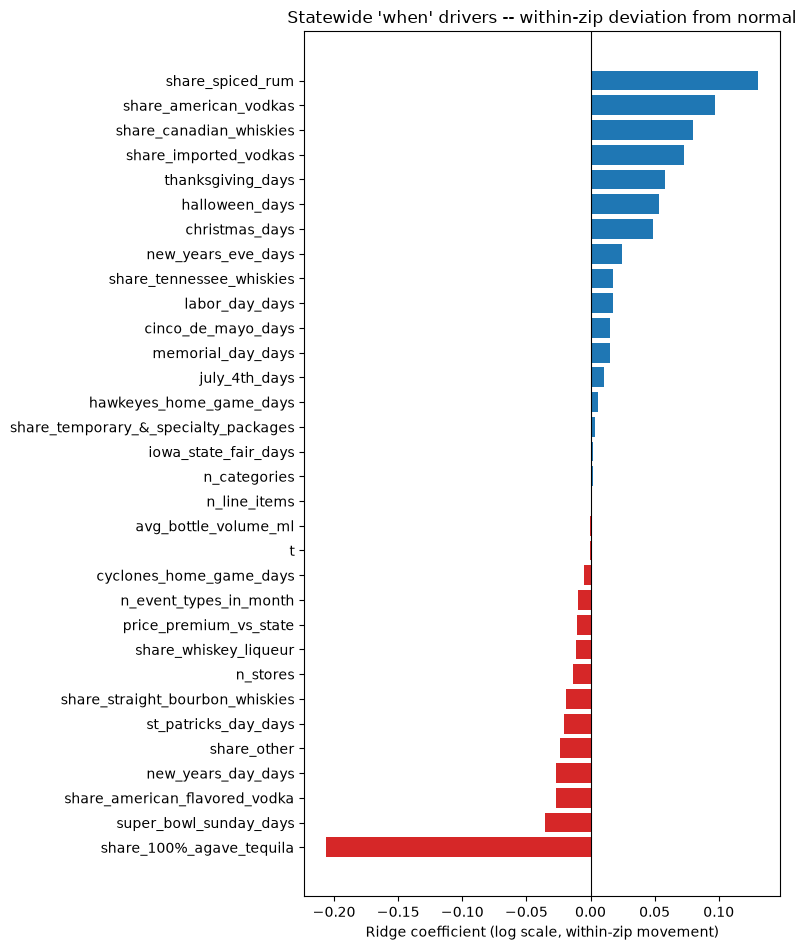

In [14]:
plot_data = coef_table.sort_values("coefficient (log scale)")
fig, ax = plt.subplots(figsize=(8, max(4, len(plot_data) * 0.3)))
colors = ["tab:red" if v < 0 else "tab:blue" for v in plot_data["coefficient (log scale)"]]
ax.barh(plot_data.index, plot_data["coefficient (log scale)"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Ridge coefficient (log scale, within-zip movement)")
ax.set_title("Statewide 'when' drivers -- within-zip deviation from normal")
plt.tight_layout()
plt.show()

## 12. Iowa City / Ames ("where"): does pooling wash out a local effect?

Exploratory, not validated the same way the statewide model was -- roughly a dozen zips
across ~56 months is too little data for a held-out split, so this is fit on everything
available and read directionally, not as a tuned predictive model. The zip lists below are
the standard residential/campus ZIPs for each city (approximate by nature of ZIP
boundaries) and are checked against what's actually present in the data, not assumed.

In [18]:
IOWA_CITY_ZIPS = {"52240", "52241", "52242", "52243", "52245", "52246"}
AMES_ZIPS = {"50010", "50011", "50012", "50013", "50014"}
college_town_zips = IOWA_CITY_ZIPS | AMES_ZIPS

college_town_data = zip_month[zip_month["zip"].isin(college_town_zips)].copy()
present = sorted(college_town_data["zip"].unique())
print(f"{len(present)} of {len(college_town_zips)} target zips present after the population floor: {present}")
print(f"{len(college_town_data):,} zip-month rows")

if len(college_town_data) > 30:
    ct_zip_avg = college_town_data.groupby("zip")["log_percapita"].transform("mean")
    ct_y_resid = college_town_data["log_percapita"] - ct_zip_avg
    ct_X = college_town_data[driver_feature_cols].fillna(0)

    college_model = Ridge(alpha=1.0).fit(ct_X, ct_y_resid)

    compare = pd.DataFrame({
        "statewide (section 11)": pd.Series(driver_model.coef_, index=driver_feature_cols),
        "Iowa City / Ames only": pd.Series(college_model.coef_, index=driver_feature_cols),
    })
    local_event_rows = ["iowa_state_fair_days", "hawkeyes_home_game_days", "cyclones_home_game_days"]
    print("\nlocal-event coefficients, statewide vs. Iowa City/Ames-only:")
    compare.loc[[c for c in local_event_rows if c in compare.index]].round(3)
else:
    print("too few rows in these zips after filtering to fit a meaningful comparison model")

6 of 11 target zips present after the population floor: ['50010', '50014', '52240', '52241', '52245', '52246']
336 zip-month rows

local-event coefficients, statewide vs. Iowa City/Ames-only:


## 13. 2026 actual vs. predicted, by model (statewide, section-8 models)

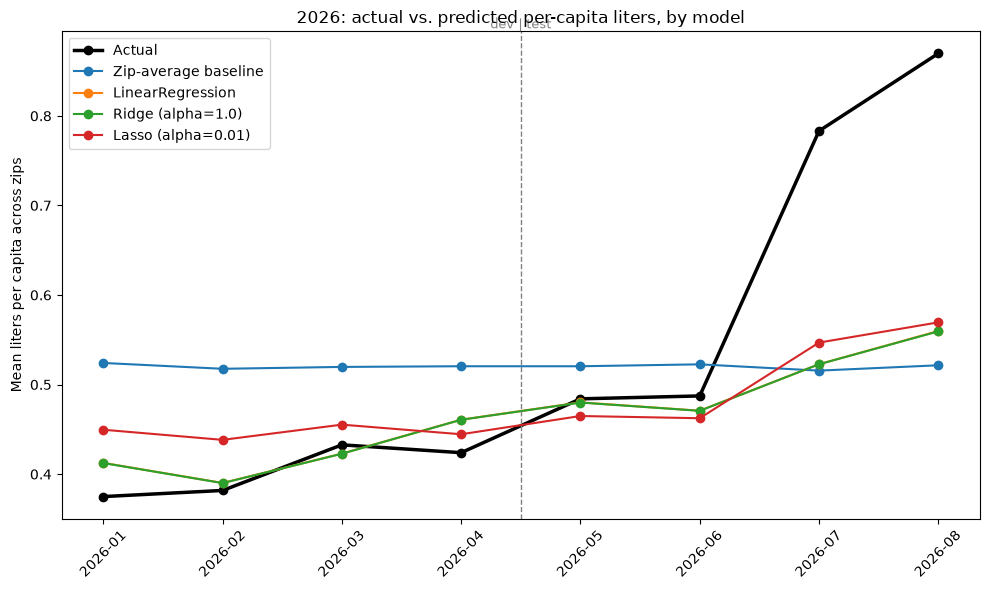

In [16]:
plot_df = pd.concat([dev, test]).copy()
for label, m in models.items():
    pred_log = m.predict(plot_df[feature_cols].fillna(0))
    plot_df[f"pred_percapita__{label}"] = np.expm1(pred_log)

months_order = sorted(plot_df["year_month"].unique())
monthly_actual = plot_df.groupby("year_month")["liters_per_capita"].mean().loc[months_order]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(months_order))
ax.plot(x, monthly_actual.values, marker="o", linewidth=2.5, color="black", label="Actual")
for label in models:
    monthly_pred = plot_df.groupby("year_month")[f"pred_percapita__{label}"].mean().loc[months_order]
    ax.plot(x, monthly_pred.values, marker="o", label=label)

ax.axvline(len(dev_months) - 0.5, color="gray", linestyle="--", linewidth=1)
ax.text(len(dev_months) - 0.5, ax.get_ylim()[1], "dev | test", ha="center", va="bottom", fontsize=9, color="gray")
ax.set_xticks(x)
ax.set_xticklabels(months_order, rotation=45)
ax.set_ylabel("Mean liters per capita across zips")
ax.set_title("2026: actual vs. predicted per-capita liters, by model")
ax.legend()
plt.tight_layout()
plt.show()

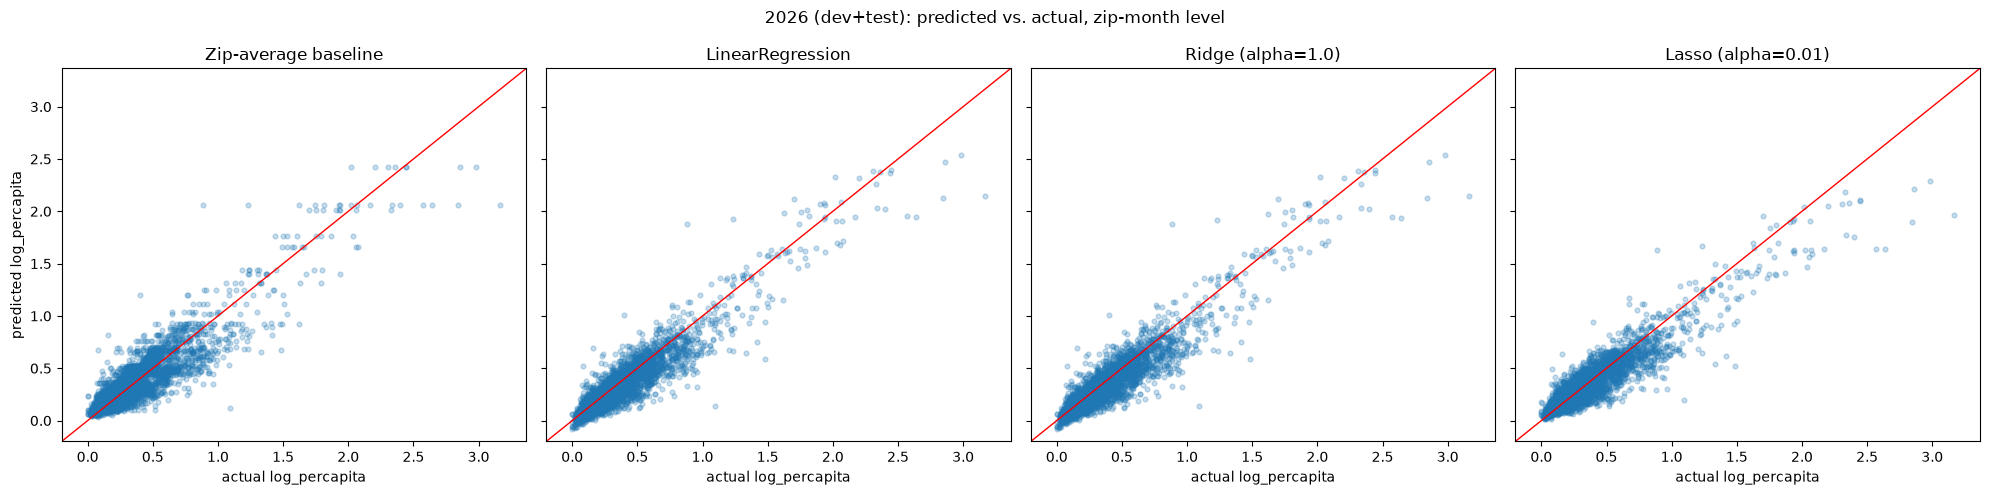

In [17]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5), sharex=True, sharey=True)
lims = [plot_df["log_percapita"].min() - 0.2, plot_df["log_percapita"].max() + 0.2]
for ax, label in zip(axes, models):
    pred_log = np.log1p(plot_df[f"pred_percapita__{label}"])
    ax.scatter(plot_df["log_percapita"], pred_log, alpha=0.25, s=12)
    ax.plot(lims, lims, color="red", linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(label)
    ax.set_xlabel("actual log_percapita")
axes[0].set_ylabel("predicted log_percapita")
plt.suptitle("2026 (dev+test): predicted vs. actual, zip-month level")
plt.tight_layout()
plt.show()

## 14. How to present this to DEAD

- **Lead with section 12 for anything about *where*** to focus outreach or programming --
  it's a real, checkable local effect in two specific, named places, not an inference from
  a statewide average.
- **Use section 11 only for *when*** -- statewide seasonal/holiday timing for campaign
  scheduling -- and say "spirits" explicitly, not "alcohol," per section 1b/6.
- **Never use the pooled statewide model to name or rank other zip codes as "problem
  areas."** It has neither the local resolution (section 12's whole point) nor the
  demographic/population precision (section 6) to support that kind of claim responsibly.
- Both sections describe correlational, aggregate, area-level patterns -- not individual
  drinking behavior, and not causation.

## 15. Takeaway for DEAD

- **Section 11's coefficients** are the "what's associated with higher per-capita spirits
  purchases, statewide, month to month" answer, now without the non-actionable zip-baseline
  bar drowning everything else out.
- **Section 12** recovers the Iowa City / Ames football/fair effect that section 11's
  pooled model structurally cannot see -- use it for targeting, not the statewide chart.
- **Section 1b's finding matters more than any single coefficient**: if this data is
  spirits-only, every claim here needs that qualifier, and beer/wine-driven occasions
  (Super Bowl Sunday being the clearest example) will always look artificially weak.
- The next highest-value addition, if DEAD wants to keep going, is **ABV/proof data** --
  per-capita liters is a real improvement over raw totals, but it's still liquid volume,
  not ethanol.

In [19]:
zip_ranking = (
    zip_month.groupby("zip")
    .agg(
        avg_liters_per_capita=("liters_per_capita", "mean"),
        avg_total_liters=("total_liters", "mean"),
        avg_population=("population", "mean"),
        n_months=("year_month", "count"),
    )
    .sort_values("avg_liters_per_capita", ascending=False)
)
zip_ranking.head(20)

,avg_liters_per_capita,avg_total_liters,avg_population,n_months
zip,,,,
52401,10.630449,23185.009196,2181.0,56
51331,8.443793,7894.946071,935.0,56
52166,7.163128,981.348482,137.0,56
50314,6.560671,68480.283393,10438.0,56
51101,4.936241,5089.264464,1031.0,56
52742,4.404913,32085.385893,7284.0,56
52314,3.272427,20289.046250,6200.0,56
52807,3.182941,49707.983571,15617.0,56
50320,2.784969,69086.725089,24807.0,56


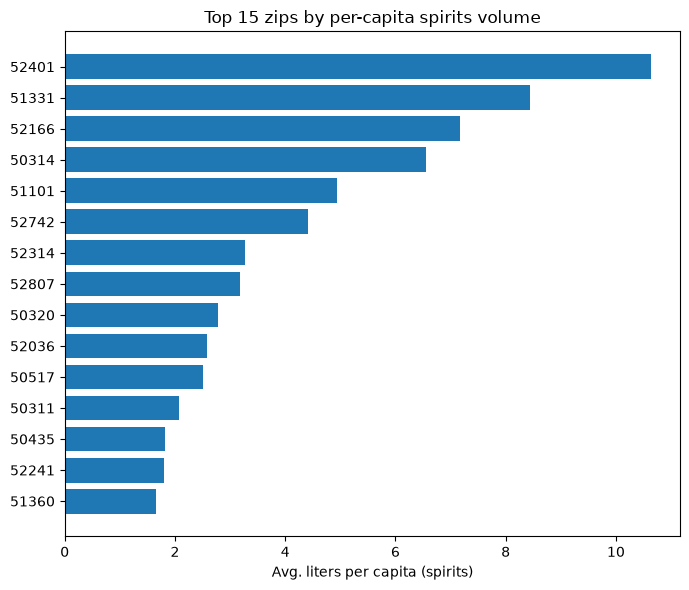

In [20]:
top15 = zip_ranking.head(15).sort_values("avg_liters_per_capita")
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top15.index.astype(str), top15["avg_liters_per_capita"])
ax.set_xlabel("Avg. liters per capita (spirits)")
ax.set_title("Top 15 zips by per-capita spirits volume")
plt.tight_layout()
plt.show()